# **Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading**


##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 7 practical sections:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: Build EdgeOffloadingEnv and Validate Environment Behavior</strong> (2-layer system: device and edge, check_env and short rollout))</li>
  <li><strong>Part 2: Baseline Policies</strong> (random, device-only, edge-only, greedy)</li>
  <li><strong>Part 3: REINFORCE</strong> (from scratch)</li>
  <li><strong>Part 4: Actor-Critic</strong> (from scratch)</li>
  <li><strong>Part 5: A2C</strong> (Stable-Baselines3)</li>
  <li><strong>Part 6: Final Comparison + Reflection</strong></li>
</ol>
</div>

In [14]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Limit PyTorch threading for kernel stability on macOS
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Reproducibility
SEED = 42
FAST_MODE = True
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device info
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Gymnasium: {gym.__version__}')
print(f'FAST_MODE: {FAST_MODE}')

# Shared plotting helpers
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.25,
})

def moving_average(values, window=20):
    """Smooth a learning curve using a moving average."""
    if len(values) == 0:
        return np.array([])
    return pd.Series(values).rolling(window=window, min_periods=1).mean().to_numpy()


def plot_curve(values, title, ylabel, window=20):
    """Plot raw values together with a moving average."""
    x = np.arange(1, len(values) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(x, values, alpha=0.35, label='Episode value')
    plt.plot(x, moving_average(values, window), lw=2, label=f'{window}-episode moving average')
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_edge_policy(env_fn, action_fn, episodes=100):
    """Evaluate a policy on EdgeOffloadingEnv and return summary metrics."""
    episode_rewards, episode_avg_latencies, all_latencies = [], [], []
    action_counts = np.zeros(2, dtype=np.int64)

    for ep in range(episodes):
        env = env_fn(SEED + 2000 + ep)
        state, _ = env.reset(seed=SEED + 2000 + ep)

        done = False
        rewards, latencies = [], []

        while not done:
            action = int(action_fn(state, env))
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            latencies.append(info['latency'])
            action_counts[action] += 1
            done = terminated or truncated

        env.close()
        episode_rewards.append(float(np.sum(rewards)))
        episode_avg_latencies.append(float(np.mean(latencies)))
        all_latencies.extend(latencies)

    all_latencies = np.array(all_latencies, dtype=np.float32)
    total_actions = int(action_counts.sum())

    return {
        'episode_rewards': np.array(episode_rewards, dtype=np.float32),
        'episode_avg_latencies': np.array(episode_avg_latencies, dtype=np.float32),
        'all_latencies': all_latencies,
        'action_counts': action_counts,
        'avg_latency': float(np.mean(all_latencies)),
        'p95_latency': float(np.percentile(all_latencies, 95)),
        'avg_reward': float(np.mean(episode_rewards)),
        'device_pct': float(action_counts[0] / total_actions * 100.0),
        'edge_pct': float(action_counts[1] / total_actions * 100.0),
    }

Device: cpu
PyTorch: 2.12.0+cpu
NumPy: 2.4.3
Gymnasium: 1.2.3
FAST_MODE: True


In [15]:
print("\n" + "="*60)
print("PART 1: EDGE OFFLOADING ENVIRONMENT")
print("="*60)

class EdgeOffloadingEnv(gym.Env):
    """Custom edge offloading environment for RL training.
    
    State: [input_size, workload, uplink_rate, edge_queue]
    Actions: 0 = device execution, 1 = edge offloading
    Reward: -latency (minimizing latency)
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, max_steps=50):
        """Initialize environment parameters.
        
        Args:
            max_steps: Maximum steps per episode
        """
        super().__init__()
        
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.max_steps = max_steps

        self.f_device = 1.0
        self.f_edge = 5.0

        self.action_space = spaces.Discrete(2) 

        low_bound = np.array([1.0, 0.1, 2.0, 0.0], dtype=np.float32)
        high_bound = np.array([20.0, 3.0, 20.0, 200.0], dtype=np.float32)
        self.observation_space = spaces.Box(
            low=low_bound,
            high=high_bound,
            dtype=np.float32
        )
        self.state = None
        self.step_count = 0


    def _sample_state(self):
        """Sample a new random state.
        
        Returns:
            State array: [input_size, workload, uplink_rate, edge_queue]
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_side = np.random.uniform(1.0, 20.0)
        workload = np.random.uniform(0.1, 3.0)
        uplink_rate = np.random.uniform(2.0, 20.0)
        edge_queue = np.random.uniform(0.0, 200.0)
        return np.array([input_side, workload, uplink_rate, edge_queue], dtype=np.float32)

    def _compute_latencies(self, state):
        """Compute execution latencies for device and edge.
        
        Args:
            state: Current state [input_size, workload, uplink_rate, edge_queue]
            
        Returns:
            Tuple (latency_device, latency_edge) in milliseconds
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        input_size, workload, uplink_rate, edge_queue = state
        t_device = (workload / self.f_device) * 1000.0
        t_upload = (input_size / uplink_rate) * 1000.0
        t_edge = t_upload + edge_queue + (workload / self.f_edge) * 1000.0
        return t_device, t_edge

    def reset(self, seed=None, options=None):
        """Reset environment to initial state.
        
        Args:
            seed: Random seed for reproducibility
            options: Additional reset options
            
        Returns:
            Tuple (observation, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        self.step_count = 0
        self.state = self._sample_state()
        info = {}
        return self.state, info

    def step(self, action):
        """Execute one step in the environment.
        
        Args:
            action: 0 for device execution, 1 for edge offloading
            
        Returns:
            Tuple (observation, reward, terminated, truncated, info)
        """
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        assert self.action_space.contains(action), f"Invalid action: {action}"
        t_device, t_edge = self._compute_latencies(self.state)

        if action == 0:
            selected_latency = t_device
            action_name = 'device'
        else:
            selected_latency = t_edge
            action_name = 'edge'
        reward = -(selected_latency/1000.0)
        self.step_count += 1
        terminated = False
        truncated = bool(self.step_count >= self.max_steps)
        info = {
            'latency': selected_latency,
            't_device': t_device,
            't_edge': t_edge,
            'action_name': action_name,
            'action': action
        }
        return self.state, reward, terminated, truncated, info

    def render(self):
        """Render current environment state."""
        if self.state is None:
            print('Environment has not been reset yet.')
        else:
            print(f'Step {self.step_count:02d} | state = {np.round(self.state, 3)}')


# Test environment initialization
print("\nInitializing EdgeOffloadingEnv...")
edge_env = EdgeOffloadingEnv(max_steps=50)
obs, info = edge_env.reset(seed=SEED)
print(f'Initial observation: {np.round(obs, 3)}')
print(f'Initial info: {info}')



PART 1: EDGE OFFLOADING ENVIRONMENT

Initializing EdgeOffloadingEnv...
Initial observation: [  8.116   2.857  15.176 119.732]
Initial info: {}


---

# PART 2: Environment Validation

Before training any policy, we validate environment API behavior and inspect transition outputs using a short random rollout.

In [16]:
# Environment validation and simple rollout test
print("\nValidating environment...")
try:
    from gymnasium.utils.env_checker import check_env
    check_env(edge_env, skip_render_check=True)
    print("✓ check_env passed successfully.")
except Exception as exc:
    print(f"check_env not available or skipped. Details: {exc}")

# Run a few steps to verify correctness
print("\nTest rollout (5 steps):")
obs, info = edge_env.reset(seed=SEED)
print(f"Initial obs: {np.round(obs, 3)}")

for step_idx in range(5):
    action = edge_env.action_space.sample()
    obs, reward, terminated, truncated, info = edge_env.step(action)
    print(f"Step {step_idx + 1}: action={action}, "
          f"reward={reward:.6f}, "
          f"latency={info['latency']:.2f}ms, "
          f"action_name={info['action_name']}")
    
    if terminated or truncated:
        obs, info = edge_env.reset(seed=SEED + step_idx + 1)
        print("  → Episode truncated, reset.")



Validating environment...
check_env not available or skipped. Details: Expects the random number generator to have been generated given a seed was passed to reset. Most likely the environment reset function does not call `super().reset(seed=seed)`.

Test rollout (5 steps):
Initial obs: [16.816  0.716  5.273 36.681]
Step 1: action=0, reward=-0.715783, latency=715.78ms, action_name=device
Step 2: action=0, reward=-0.715783, latency=715.78ms, action_name=device
Step 3: action=0, reward=-0.715783, latency=715.78ms, action_name=device
Step 4: action=0, reward=-0.715783, latency=715.78ms, action_name=device
Step 5: action=0, reward=-0.715783, latency=715.78ms, action_name=device


---

# PART 3: Baseline Policies and Evaluation

Before training RL algorithms, we establish baseline policies to understand expected latency and reward scales.

### 3.1 Policy Implementations

We implement four baseline policies:
- **Random**: choose action uniformly at random
- **Device-only**: always execute on device
- **Edge-only**: always offload to edge
- **Greedy latency**: choose action with lower immediate latency


In [17]:
# ============================================================================
# Baseline policy functions
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def random_policy(state, env):
    return env.action_space.sample()
def device_only_policy(state, env):
    return 0
def edge_only_policy(state, env):
    return 1
def greedy_latency_policy(state, env):
    t_device, t_edge = env._compute_latencies(state)
    return 0 if t_device <= t_edge else 1

In [18]:
# ============================================================================
# Evaluate baseline policies
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
env_fn = lambda seed: EdgeOffloadingEnv(max_steps=50)
policies = {
    'Random': random_policy,
    'Device Only': device_only_policy,
    'Edge Only': edge_only_policy,
    'Greedy Latency': greedy_latency_policy
}
baseline_results = {}
print("\nEvaluating baseline policies...")
for name, policy_fn in policies.items():
    print(f"Evaluating {name} policy...")
    results = evaluate_edge_policy(env_fn, policy_fn, episodes=100)
    baseline_results[name] = results
    print(f"  → Avg Reward: {results['avg_reward']:.4f}, "
          f"Avg Latency: {results['avg_latency']:.2f}ms, "
          f"P95 Latency: {results['p95_latency']:.2f}ms, "
          f"Device %: {results['device_pct']:.1f}%, "
          f"Edge %: {results['edge_pct']:.1f}%")


Evaluating baseline policies...
Evaluating Random policy...
  → Avg Reward: -79.6077, Avg Latency: 1592.15ms, P95 Latency: 2971.16ms, Device %: 50.7%, Edge %: 49.3%
Evaluating Device Only policy...
  → Avg Reward: -80.1768, Avg Latency: 1603.54ms, P95 Latency: 2893.61ms, Device %: 100.0%, Edge %: 0.0%
Evaluating Edge Only policy...
  → Avg Reward: -90.8206, Avg Latency: 1816.41ms, P95 Latency: 4258.53ms, Device %: 0.0%, Edge %: 100.0%
Evaluating Greedy Latency policy...
  → Avg Reward: -59.4037, Avg Latency: 1188.07ms, P95 Latency: 2469.95ms, Device %: 56.0%, Edge %: 44.0%


---

# PART 4: Actor-Critic on EdgeOffloadingEnv

Actor-Critic combines a policy (actor) and a value estimator (critic) for more stable learning than REINFORCE.

### 5.1 Actor and Critic Networks

- **Actor**: outputs action probabilities
- **Critic**: estimates the state value for temporal-difference learning


In [19]:
print("\n" + "="*60)
print("PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV")
print("="*60)

# ============================================================================
# Actor and Critic networks
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size=128):
        super(ActorCritic, self).__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU()
        )
        self.actor = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        
    def forward(self, state):
        shared_out = self.shared(state)
        action_probs = self.actor(shared_out)
        state_value = self.critic(shared_out)
        return action_probs, state_value


PART 4: ACTOR-CRITIC ON EDGE OFFLOADING ENV


Initiating Actor-Critic training...
training Actor-Critic agent...


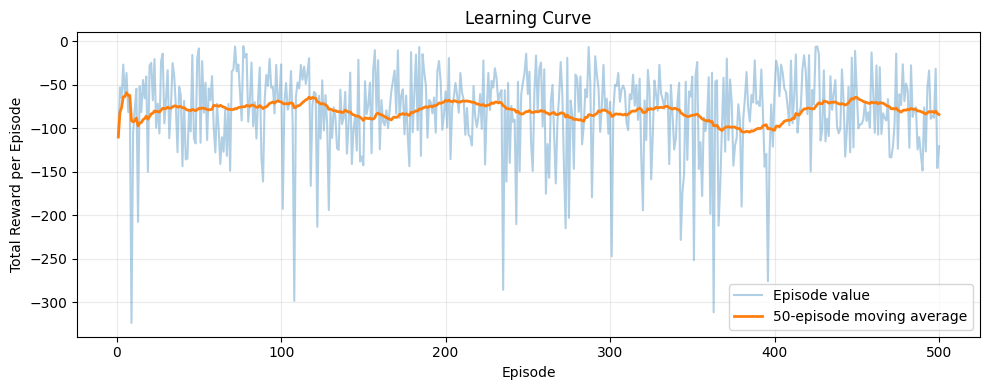


evaluating Actor-Critic policy...
  → Avg Latency: 1501.43 ms
  → P95 Latency: 2825.21 ms
  → Avg Reward:  -75.07
  → Action Distribution: Device 100.0% / Edge 0.0%



In [20]:
# ============================================================================
# Actor-Critic training analysis
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
def train_actor_critic(env, model, optimizer, num_episodes=600, gamma=0.99):
    episode_rewards = []
    
    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        ep_reward = 0.0

        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            action_probs, state_value = model(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            
            # Compute advantage and update model
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
            _, next_state_value = model(next_state_tensor)
            if done:
                td_target = torch.tensor([[reward]], dtype=torch.float32).to(device)
            else:
                td_target = reward + gamma * next_state_value.detach()
            td_error = td_target - state_value

            actor_loss = -dist.log_prob(action) * td_error.detach()
            critic_loss = nn.functional.mse_loss(state_value, td_target)
            total_loss = actor_loss + critic_loss

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            ep_reward += reward
            state = next_state
            
        episode_rewards.append(ep_reward)

    return episode_rewards

print("Initiating Actor-Critic training...")
train_env = EdgeOffloadingEnv(max_steps=50)
obs_dim = train_env.observation_space.shape[0]
act_dim = train_env.action_space.n

ac_model = ActorCritic(obs_dim, act_dim).to(device)
ac_optimizer = optim.Adam(ac_model.parameters(), lr=2e-3)

print("training Actor-Critic agent...")
ac_rewards = train_actor_critic(train_env, ac_model, ac_optimizer, num_episodes=500)

# Vẽ đồ thị học tập (sử dụng hàm plot_curve có sẵn ở cell đầu)
plot_curve(ac_rewards, "Learning Curve", "Total Reward per Episode", window=50)

# --- ĐÁNH GIÁ MÔ HÌNH ---
print("\nevaluating Actor-Critic policy...")

def ac_inference_policy(state, env):
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        action_probs, _ = ac_model(state_tensor)
        return torch.argmax(action_probs).item()

ac_eval_result = evaluate_edge_policy(lambda seed: EdgeOffloadingEnv(max_steps=50), ac_inference_policy, episodes=100)

# Lưu lại kết quả vào dictionary chung (để dùng cho Part 6)
if 'baseline_results' not in globals():
    baseline_results = {}
baseline_results['Actor-Critic'] = ac_eval_result

print(f"  → Avg Latency: {ac_eval_result['avg_latency']:.2f} ms")
print(f"  → P95 Latency: {ac_eval_result['p95_latency']:.2f} ms")
print(f"  → Avg Reward:  {ac_eval_result['avg_reward']:.2f}")
print(f"  → Action Distribution: Device {ac_eval_result['device_pct']:.1f}% / Edge {ac_eval_result['edge_pct']:.1f}%\n")

---

# PART 5: A2C 


### 6.1 A2C Training and Evaluation


In [ ]:
print("\n" + "="*60)
print("PART 5: A2C (OPTIONAL, STABLE-BASELINES3)")
print("="*60)

# ============================================================================
# A2C training and evaluation
# ============================================================================

### YOU NEED TO WRITE YOUR CODE BELOW ###
# Import thuật toán A2C từ thư viện
from stable_baselines3 import A2C

print("Khởi tạo môi trường cho A2C...")
# Môi trường phải được bọc lại hoặc khởi tạo chuẩn, ở đây ta dùng thẳng env đã viết
a2c_env = EdgeOffloadingEnv(max_steps=50)

print("Đang huấn luyện A2C bằng Stable-Baselines3 (sẽ mất một chút thời gian)...")
# Khởi tạo mô hình A2C với mạng Multi-Layer Perceptron (MlpPolicy)
# Seed được set để kết quả ổn định. verbose=0 để tắt log rác
a2c_model = A2C(
    "MlpPolicy", 
    a2c_env, 
    ent_coef=0.01,    
    n_steps=20,       
    learning_rate=0.0005, 
    verbose=0, 
    seed=SEED
)

# Huấn luyện mô hình trong 25,000 bước (tương đương khoảng 500 episodes)
a2c_model.learn(total_timesteps=100000)

print("Huấn luyện xong! Đang đánh giá chính sách của SB3...")

# Viết một hàm bọc (wrapper policy) để tương thích với hàm evaluate_edge_policy của Lab
def a2c_sb3_policy(state, env):
    # predict() của SB3 trả về action và hidden_state (nếu dùng RNN), ta chỉ cần lấy action
    action, _ = a2c_model.predict(state, deterministic=True)
    return int(action)

# Đánh giá 100 episodes
a2c_eval_result = evaluate_edge_policy(lambda seed: EdgeOffloadingEnv(max_steps=50), a2c_sb3_policy, episodes=100)

# Lưu kết quả vào dictionary dùng chung
if 'baseline_results' not in globals():
    baseline_results = {}
baseline_results['A2C (SB3)'] = a2c_eval_result

# In kết quả
print(f"  → Avg Latency: {a2c_eval_result['avg_latency']:.2f} ms")
print(f"  → P95 Latency: {a2c_eval_result['p95_latency']:.2f} ms")
print(f"  → Avg Reward:  {a2c_eval_result['avg_reward']:.2f}")
print(f"  → Phân bổ hành động: Thiết bị {a2c_eval_result['device_pct']:.1f}% / Cạnh (Edge) {a2c_eval_result['edge_pct']:.1f}%\n")


PART 5: A2C (OPTIONAL, STABLE-BASELINES3)
Khởi tạo môi trường cho A2C...
Đang huấn luyện A2C bằng Stable-Baselines3 (sẽ mất một chút thời gian)...
Huấn luyện xong! Đang đánh giá chính sách của SB3...
  → Avg Latency: 1279.62 ms
  → P95 Latency: 2785.10 ms
  → Avg Reward:  -63.98
  → Phân bổ hành động: Thiết bị 49.0% / Cạnh (Edge) 51.0%



---

# PART 6: Final Comparison

We compare all methods (baseline policies, Actor-Critic, and A2C) using shared evaluation metrics.

### 7.1 Aggregated Results Table


In [ ]:
# ============================================================================
# Build comprehensive comparison table
# ============================================================================

comparison_rows = []

def add_result(method_name, result):
    """Add a result row to the comparison table.
    
    Args:
        method_name: Name of the method
        result: Evaluation result dictionary
    """
    comparison_rows.append({
        'Method': method_name,
        'Avg Latency ↓': result['avg_latency'],
        'P95 Latency ↓': result['p95_latency'],
        'Avg Reward ↑': result['avg_reward'],
        'Gap to Greedy ↓': result['avg_latency'] - baseline_results['Greedy latency']['avg_latency'],
        'Device %': result['device_pct'],
        'Edge %': result['edge_pct'],
    })


### YOU NEED TO WRITE YOUR CODE BELOW ###

## CONGRATULATIONS TEAM!

Congratulations on Completing Lab 04.2 - Policy-Based Reinforcement Learning for Edge Offloading!

**Key Observations:**

- **REINFORCE** is simple but often has high-variance updates.
- **Actor-Critic** is usually more stable due to TD-based critic guidance.
- **A2C** is a practical implementation of actor-critic methods.
- On EdgeOffloadingEnv, learned policies can approach strong heuristic behavior.
- The task highlights trade-offs between communication latency and compute placement decisions.

**Why This Matters:**

- Edge systems require fast adaptive offloading decisions.
- Policy-based RL provides a data-driven alternative to hand-crafted decision rules.
- These methods form a foundation for many advanced RL algorithms used in networking systems.

References: https://gymnasium.farama.org/ | https://pytorch.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026